In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import os
import requests
import time

BASE    = '/content/drive/MyDrive/Solar_cold_storage'
RAW     = f'{BASE}/raw'
CLEANED = f'{BASE}/cleaned'
os.makedirs(CLEANED, exist_ok=True)

# === All constants from literature ===
ICAR_LOSS = {
    'tomato':12.44, 'mango':9.16, 'onion':8.20,
    'potato':7.32,  'banana':7.76, 'grapes':8.63,
    'pomegranate':9.00
}

NHB_TEMP = {
    'tomato':14.0, 'mango':14.0, 'onion':2.0,
    'potato':4.0,  'banana':13.0, 'grapes':1.0,
    'pomegranate':5.0
}

# Per-crop Arrhenius activation energy (J/mol) — Kader 2002
ARRHENIUS = {
    'tomato':     {'Ea':45200, 'sl_ref':48,  'T_ref':25},
    'mango':      {'Ea':46450, 'sl_ref':96,  'T_ref':25},
    'banana':     {'Ea':44000, 'sl_ref':72,  'T_ref':25},
    'grapes':     {'Ea':47000, 'sl_ref':120, 'T_ref':25},
    'onion':      {'Ea':38000, 'sl_ref':720, 'T_ref':25},
    'pomegranate':{'Ea':43000, 'sl_ref':168, 'T_ref':25},
    'potato':     {'Ea':40000, 'sl_ref':480, 'T_ref':25},
}

# Specific heat kJ/kg°C — ASHRAE Handbook
SPECIFIC_HEAT = {
    'tomato':3.99, 'mango':3.90, 'banana':3.35,
    'grapes':3.60, 'onion':3.91, 'pomegranate':3.74,
    'potato':3.43
}

# Chamber groups
CHAMBERS = {
    'Warm (13-15°C)': {'crops':['tomato','mango','banana'], 'temp_c':14.0},
    'Cool (4-6°C)':   {'crops':['potato','pomegranate'],    'temp_c':5.0},
    'Cold (1-3°C)':   {'crops':['grapes','onion'],          'temp_c':2.0},
}

# Solar + sizing constants
PANEL_W      = 500    # watts
PANEL_AREA   = 1.7    # m²
PANEL_EFF    = 0.20   # monocrystalline
SYSTEM_EFF   = 0.80   # inverter losses
COP          = 3.0    # refrigeration COP
UNIT_MT      = 500    # MT per cold storage unit
MARKET_DAYS  = 26     # trading days per month

# District coordinates for NASA POWER
DISTRICT_COORDS = {
    'Bagalkot':(16.1691,75.6966), 'Ballari':(15.1394,76.9214),
    'Belagavi':(15.8497,74.4977), 'Bengaluru Rural':(13.1986,77.7066),
    'Bengaluru Urban':(12.9716,77.5946), 'Bidar':(17.9104,77.5199),
    'Chamarajanagar':(11.9261,76.9437), 'Chikkaballapura':(13.4354,77.7282),
    'Chikkamagaluru':(13.3161,75.7720), 'Chitradurga':(14.2251,76.3980),
    'Dakshina Kannada':(12.8438,74.9900), 'Davangere':(14.4644,75.9218),
    'Dharwad':(15.4589,75.0078), 'Gadag':(15.4166,75.6220),
    'Hassan':(13.0034,76.1004), 'Haveri':(14.7957,75.3996),
    'Kalaburagi':(17.3297,76.8200), 'Kodagu':(12.3375,75.8069),
    'Kolar':(13.1306,78.1352), 'Koppal':(15.3508,76.1547),
    'Mandya':(12.5218,76.8950), 'Mysuru':(12.2958,76.6394),
    'Raichur':(16.2120,77.3566), 'Ramanagara':(12.7157,77.2817),
    'Shivamogga':(13.9299,75.5681), 'Tumakuru':(13.3379,77.1173),
    'Udupi':(13.3409,74.7421), 'Uttara Kannada':(14.7941,74.6938),
    'Vijayanagara':(15.1394,76.5204), 'Vijayapura':(16.8302,75.7100),
}

print("✅ Setup complete")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup complete


In [ ]:
!pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.2 MB/s eta 0:00:00


In [ ]:
import ruptures as rpt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# Load
monthly  = pd.read_csv(f'{CLEANED}/karnataka_monthly_arrivals.csv')
monthly['month'] = pd.to_datetime(monthly['month'])
EXCLUDE  = ['Bengaluru Urban', 'Bengaluru Rural']
monthly  = monthly[~monthly['district'].isin(EXCLUDE)]

# Load or fetch NASA POWER
nasa_path = f'{CLEANED}/karnataka_nasa_power.csv'
if os.path.exists(nasa_path):
    nasa_raw = pd.read_csv(nasa_path)
    nasa_raw['month'] = pd.to_datetime(nasa_raw['month'])
    print("✅ NASA loaded from file")
else:
    print("Fetching NASA POWER...")
    rows = []
    for district, (lat, lon) in DISTRICT_COORDS.items():
        url = (f"https://power.larc.nasa.gov/api/temporal/monthly/point?"
               f"parameters=ALLSKY_SFC_SW_DWN,T2M&community=RE"
               f"&longitude={lon}&latitude={lat}&start=2021&end=2025&format=JSON")
        try:
            data  = requests.get(url, timeout=30).json()['properties']['parameter']
            solar = data['ALLSKY_SFC_SW_DWN']
            temp  = data['T2M']
            for k in solar:
                if k.endswith('13'): continue
                yr, mo = int(k[:4]), int(k[4:])
                rows.append({'district':district,
                             'month':pd.Timestamp(year=yr,month=mo,day=1),
                             'month_name':pd.Timestamp(year=yr,month=mo,day=1).strftime('%b').upper(),
                             'solar_kwh_m2':solar[k],
                             'ambient_temp_c':temp[k]})
            print(f"  {district} ✅")
        except: print(f"  {district} ❌")
        time.sleep(0.3)
    nasa_raw = pd.DataFrame(rows)
    nasa_raw['month'] = pd.to_datetime(nasa_raw['month'])
    nasa_raw.to_csv(nasa_path, index=False)

nasa_avg = nasa_raw.groupby(['district','month_name']).agg(
    solar_kwh_m2   =('solar_kwh_m2','mean'),
    ambient_temp_c =('ambient_temp_c','mean')
).reset_index()

# === Agentic model selector ===
def run_cusum(series):
    """Returns cleaned series after last shock"""
    try:
        model = rpt.Pelt(model="rbf").fit(series.values)
        bkps  = model.predict(pen=3000)
        if len(bkps) > 1:
            last = bkps[-2]
            if last > len(series) * 0.3:
                return series.iloc[last:].copy()
    except: pass
    return series

def run_sarimax(df):
    ts = df.set_index('month')['arrivals_mt'].sort_index()
    hist_max = float(ts.max())

    try:
        ts = ts.resample('MS').sum()

        result = SARIMAX(
            ts,
            order=(1,1,1),
            seasonal_order=(0,1,1,12),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=100)

        fc = result.forecast(steps=12)

        # Reject unstable forecasts
        if (
            not np.isfinite(fc).all()
            or abs(fc.max()) > 1e6
            or fc.max() <= 0
        ):
            return hist_max, df.loc[df['arrivals_mt'].idxmax(), 'month_name']

        peak = min(float(fc.max()), 3 * hist_max)
        return peak, fc.idxmax().strftime('%b').upper()

    except Exception:
        return hist_max, df.loc[df['arrivals_mt'].idxmax(), 'month_name']

def run_prophet(df):
    pdf         = df[['month','arrivals_mt']].rename(columns={'month':'ds','arrivals_mt':'y'})
    pdf['y']    = pdf['y'].clip(lower=0)
    hist_max    = float(pdf['y'].max())
    try:
        m      = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                         daily_seasonality=False, seasonality_mode='multiplicative')
        m.fit(pdf)
        future = m.make_future_dataframe(periods=12, freq='MS')
        fc     = m.predict(future)
        fc_fut = fc.tail(12)
        peak   = min(float(fc_fut['yhat'].max()), 3*hist_max)
        peak_m = fc_fut.loc[fc_fut['yhat'].idxmax(),'ds'].strftime('%b').upper()
        return max(peak, 0), peak_m
    except: return hist_max, df.loc[df['arrivals_mt'].idxmax(),'month_name']

def select_and_forecast(df):
    """Agentic model selector"""
    n = len(df)
    if n >= 20:
        forecast, peak_month = run_sarimax(df)
        model = 'SARIMAX'
    elif n >= 8:
        forecast, peak_month = run_prophet(df)
        model = 'Prophet'
    else:
        forecast  = float(df['arrivals_mt'].max())
        peak_month = df.loc[df['arrivals_mt'].idxmax(),'month_name']
        model     = 'Historical max'
    return forecast, peak_month, model

# === Run for all district-crop combinations ===
print("Running CUSUM + Agentic Forecast for all district-crop combinations...")
forecast_results = []
combos = monthly.groupby(['district','crop'])
total  = len(combos)
count  = 0

for (district, crop), df in combos:
    count += 1
    df = df.sort_values('month').reset_index(drop=True)

    # CUSUM — remove shocks
    cleaned   = run_cusum(df['arrivals_mt'])
    df_clean  = df.iloc[cleaned.index if hasattr(cleaned.index,'start') else df.index].copy()
    if len(df_clean) < 6: df_clean = df.copy()

    # Price features from original (before shock removal)
    avg_price       = df['avg_price'].mean() if 'avg_price' in df.columns else 1000
    price_vol       = df['price_volatility'].mean() if 'price_volatility' in df.columns else 200
    best_mandi      = df['best_mandi'].iloc[0] if 'best_mandi' in df.columns else 'Unknown'

    # Forecast
    forecast, peak_month, model = select_and_forecast(df_clean)

    # Get climate for peak month
    climate = nasa_avg[(nasa_avg['district']==district) &
                       (nasa_avg['month_name']==peak_month)]
    if len(climate) == 0:
        climate = nasa_avg[nasa_avg['district']==district]
        if len(climate) == 0: continue

    peak_temp  = float(climate['ambient_temp_c'].mean())
    peak_solar = float(climate['solar_kwh_m2'].mean())

    forecast_results.append({
        'district':      district,
        'crop':          crop,
        'best_mandi':    best_mandi,
        'n_months':      len(df),
        'model_used':    model,
        'peak_forecast_mt': round(forecast, 1),
        'peak_month':    peak_month,
        'peak_temp_c':   round(peak_temp, 2),
        'peak_solar':    round(peak_solar, 4),
        'avg_price':     round(avg_price, 1),
        'price_vol':     round(price_vol, 1),
        'icar_loss_rate': ICAR_LOSS.get(crop, 9.0),
        'nhb_ideal_temp_c': NHB_TEMP.get(crop, 8.0),
    })

    if count % 20 == 0:
        print(f"  {count}/{total} done...")

forecast_df = pd.DataFrame(forecast_results)
forecast_df.to_csv(f'{CLEANED}/agentic_forecasts.csv', index=False)

print(f"\n✅ Forecasting complete: {len(forecast_df)} district-crop combinations")
print(f"\nModel usage:")
print(forecast_df['model_used'].value_counts().to_string())

✅ NASA loaded from file
Running CUSUM + Agentic Forecast for all district-crop combinations...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
INFO:prophet:n_changepoints greater than number of observations. Using 9.


  20/104 done...


INFO:prophet:n_changepoints greater than number of observations. Using 9.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
INFO:prophet:n_changepoints greater than number of observations. Using 11.


  40/104 done...


...

  80/104 done...


INFO:prophet:n_changepoints greater than number of observations. Using 7.
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  100/104 done...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



✅ Forecasting complete: 104 district-crop combinations

Model usage:
model_used
SARIMAX           72
Historical max    22
Prophet           10


=== After feature engineering ===
   peak_forecast_mt  daily_arrivals  daily_at_risk_mt
8             113.0        4.346154          0.356385
=== FEATURE IMPORTANCE LEARNED BY XGBoost ===
        feature  importance
      avg_price    0.358666
  cooling_gap_c    0.356717
shelf_life_days    0.228331
      price_vol    0.051785
     peak_solar    0.004500


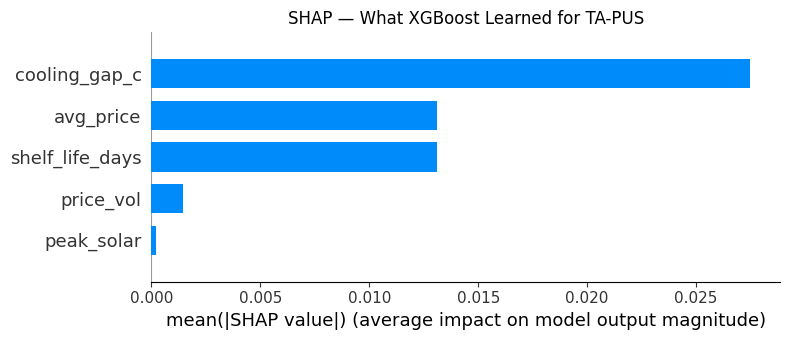

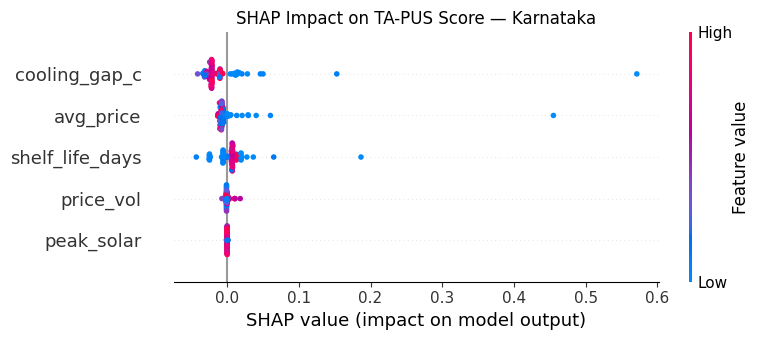


✅ XGBoost TA-PUS complete: 96 combinations

Top 10 most urgent district-crop combinations:
       district   crop  TA_PUS_Score  peak_forecast_mt peak_month  shelf_life_days     model_used
          Kolar tomato        1.0000           77432.2        JUN         2.048341        SARIMAX
          Kolar  mango        0.7990           78382.4        DEC         5.251762        Prophet
Chikkaballapura tomato        0.1864           16569.8        JUL         2.137077        SARIMAX
   Vijayanagara tomato        0.0794             250.1        MAR         1.571060        SARIMAX
        Raichur  onion        0.0740            5953.4        MAR        22.873405        SARIMAX
     Vijayapura  onion        0.0727            7133.2        APR        21.084863        SARIMAX
       Tumakuru  mango        0.0673            1069.8        NOV         4.829956        Prophet
Chikkaballapura  mango        0.0667             679.0        JUL         4.281996 Historical max
         Haveri tomato    

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
import shap
import matplotlib.pyplot as plt

R = 8.314

def shelf_life_days(T_C, crop):
    p    = ARRHENIUS[crop]
    T_K  = T_C + 273.15
    Tref = p['T_ref'] + 273.15
    k0   = (1/p['sl_ref']) / np.exp(-p['Ea']/(R*Tref))
    return max(1/(k0*np.exp(-p['Ea']/(R*T_K)))/24, 0.1)






df = forecast_df.copy()


# === Arrhenius features ===
df['shelf_life_days'] = df.apply(
    lambda r: shelf_life_days(r['peak_temp_c'], r['crop']), axis=1)
df['cooling_gap_c']   = (df['peak_temp_c'] - df['nhb_ideal_temp_c']).clip(lower=0.1)

# === TARGET — non-circular ===
# Daily at-risk volume: how many MT per day goes unsold and needs cold storage
# This is based on arrivals + ICAR loss rate
# Arrivals NOT used as a feature — only as target basis
df['daily_arrivals']   = df['peak_forecast_mt'] / MARKET_DAYS
df['daily_at_risk_mt'] = df['daily_arrivals'] * (df['icar_loss_rate'] / 100)
print("=== After feature engineering ===")
print(
    df.loc[
        (df["district"] == "Chamarajanagar") &
        (df["crop"] == "onion"),
        ["peak_forecast_mt", "daily_arrivals", "daily_at_risk_mt"]
    ]
)


feature_cols = [
    'shelf_life_days',
    'cooling_gap_c',
    'peak_solar',
    'price_vol',
    'avg_price',
]

# Drop rows with missing features
df_train = df.dropna(subset=feature_cols + ['daily_at_risk_mt']).copy()

X = df_train[feature_cols]
y = df_train['daily_at_risk_mt']

# Scale features
scaler_X = MinMaxScaler()
X_scaled = pd.DataFrame(scaler_X.fit_transform(X), columns=feature_cols)

# Scale target to 0-1
scaler_y = MinMaxScaler(feature_range=(0,1))
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1)).flatten()

# === Train XGBoost ===
model = XGBRegressor(
    n_estimators=100, max_depth=3,
    learning_rate=0.05, subsample=0.8,
    random_state=42
)
model.fit(X_scaled, y_scaled)

print("=== FEATURE IMPORTANCE LEARNED BY XGBoost ===")
imp = pd.DataFrame({
    'feature':    feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print(imp.to_string(index=False))

# === Predict TA-PUS ===
df_train['TA_PUS_raw'] = model.predict(X_scaled)

# Scale to 0-1 relative to training range
tap_scaler = MinMaxScaler(feature_range=(0,1))
df_train['TA_PUS_Score'] = tap_scaler.fit_transform(
    df_train[['TA_PUS_raw']]).round(4)

# === SHAP ===
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)

plt.figure(figsize=(10,5))
shap.summary_plot(shap_values, X_scaled, plot_type='bar', show=False)
plt.title('SHAP — What XGBoost Learned for TA-PUS')
plt.tight_layout()
plt.savefig(f'{CLEANED}/shap_karnataka_bar.png', dpi=150)
plt.show()

plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_scaled, show=False)
plt.title('SHAP Impact on TA-PUS Score — Karnataka')
plt.tight_layout()
plt.savefig(f'{CLEANED}/shap_karnataka_dot.png', dpi=150)
plt.show()

print(f"\n✅ XGBoost TA-PUS complete: {len(df_train)} combinations")
print("\nTop 10 most urgent district-crop combinations:")
print(df_train.nlargest(10,'TA_PUS_Score')[
    ['district','crop','TA_PUS_Score','peak_forecast_mt',
     'peak_month','shelf_life_days','model_used']
].to_string(index=False))

df_train.to_csv(f'{CLEANED}/tapus_scores_all.csv', index=False)
print("✅ Saved tapus_scores_all.csv")

shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP|": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean |SHAP|", ascending=False
)

print(shap_importance)


In [ ]:
# Load existing capacity
existing = pd.read_csv(f'{CLEANED}/karnataka_existing_capacity.csv')
existing_map = existing.set_index('district')['existing_capacity_mt'].to_dict()

crop_df = df_train.copy()
# === Solar panels per unit (daily intake method) ===
def solar_panels(cool_gap_c, solar_kwh_m2, crop):
    daily_intake_kg  = (UNIT_MT * 1000) / 15  # 15-day storage turnover
    sh               = SPECIFIC_HEAT.get(crop, 3.9)
    cooling_kwh      = daily_intake_kg * sh * cool_gap_c / 3600 / COP
    panel_kwh_day    = solar_kwh_m2 * PANEL_AREA * PANEL_EFF * SYSTEM_EFF
    return max(int(np.ceil(cooling_kwh / panel_kwh_day)), 1)



crop_df['panels_per_unit'] = crop_df.apply(
    lambda r: solar_panels(r['cooling_gap_c'], r['peak_solar'], r['crop']), axis=1)

# === Units needed ===
# daily_at_risk_mt is how many MT per day needs cold storage
# Divide by 500 MT unit size to get units
# Then subtract existing capacity (in units)
def units_needed(district, daily_at_risk):
    existing_mt    = existing_map.get(district, 0)
    existing_units = existing_mt / UNIT_MT
    required_units = daily_at_risk / UNIT_MT
    new_units      = max(int(np.ceil(required_units - existing_units)), 0)
    return min(new_units, 10)  # cap at 10 per district-crop

crop_df['units_needed'] = crop_df.apply(
    lambda r: units_needed(r['district'], r['daily_at_risk_mt']), axis=1)

# === District-level combined TA-PUS ===
district_df = crop_df.groupby('district').agg(
    combined_urgency    = ('TA_PUS_Score', 'sum'),
    total_units         = ('units_needed', 'sum'),
    total_daily_at_risk = ('daily_at_risk_mt', 'sum'),
    crops_present       = ('crop', lambda x: ', '.join(sorted(x))),
    peak_crop           = ('TA_PUS_Score', lambda x:
                           crop_df.loc[x.idxmax(),'crop']),
    best_mandi          = ('TA_PUS_Score', lambda x:
                           crop_df.loc[x.idxmax(),'best_mandi']),
    model_mix           = ('model_used', lambda x:
                           ', '.join(x.unique())),
).reset_index()

# Normalize combined urgency to 0-1
from scipy.stats import rankdata

district_df['TA_PUS_Score'] = (
    rankdata(district_df['combined_urgency'])
    / len(district_df)
).round(4)

district_df = district_df.sort_values(
    'TA_PUS_Score', ascending=False).reset_index(drop=True)

# === Multi-chamber recommendations ===
chamber_rows = []
for district in district_df['district']:
    dist_crops  = crop_df[crop_df['district'] == district]
    existing_mt = existing_map.get(district, 0)

    for ch_name, info in CHAMBERS.items():
        ch_crops = dist_crops[dist_crops['crop'].isin(info['crops'])]
        if len(ch_crops) == 0: continue

        # Total daily at-risk for this chamber
        at_risk = round(ch_crops['daily_at_risk_mt'].sum(), 2)

        # Total district at-risk
        total_at_risk = dist_crops['daily_at_risk_mt'].sum()

        # Proportional allocation of existing capacity
        if total_at_risk > 0:
            chamber_weight = at_risk / total_at_risk
        else:
            chamber_weight = 0

        proportional_existing_mt = existing_mt * chamber_weight

        existing_units = proportional_existing_mt / UNIT_MT

        required_units = at_risk / UNIT_MT

        units = max(
            int(np.ceil(required_units - existing_units)),
            0
        )

        units = min(units, 10)

        panels = int(ch_crops['panels_per_unit'].max())
        crops_in = ', '.join(ch_crops['crop'].tolist())
        peak_months = ', '.join(ch_crops['peak_month'].unique())
        capacity = units * UNIT_MT

        chamber_rows.append({
            'district':        district,
            'chamber':         ch_name,
            'storage_temp_c':  info['temp_c'],
            'crops_stored':    crops_in,
            'units_needed':    units,
            'capacity_mt':     capacity,
            'panels_per_unit': panels,
            'total_panels':    units * panels,
            'peak_months':     peak_months,
            'daily_at_risk_mt': at_risk,
        })

chamber_df = pd.DataFrame(chamber_rows)

# =====================================================
# Update district total_units from chamber recommendations
# =====================================================
district_units = (
    chamber_df.groupby("district")["units_needed"]
    .sum()
    .reset_index(name="total_units")
)

# Remove the old total_units column
district_df = district_df.drop(columns=["total_units"])

# Merge the corrected totals
district_df = district_df.merge(
    district_units,
    on="district",
    how="left"
)

district_df["total_units"] = (
    district_df["total_units"]
    .fillna(0)
    .astype(int)
)

# === Print results ===
print("="*70)
print("KARNATAKA — DISTRICT TA-PUS RANKING (ALL CROPS COMBINED)")
print("="*70)
print(
    district_df[
        ['district','TA_PUS_Score','total_units',
         'peak_crop','best_mandi','crops_present']
    ].to_string(index=False)
)

print("\n" + "="*70)
print("MULTI-CHAMBER RECOMMENDATIONS — TOP 10 DISTRICTS")
print("="*70)

for district in district_df.head(10)['district']:

    score = district_df.loc[
        district_df['district']==district,
        'TA_PUS_Score'
    ].iloc[0]

    ex_mt = existing_map.get(district,0)

    print(f"\n{'─'*65}")
    print(f"{district.upper()} — TA-PUS: {score:.4f} | Existing Capacity: {ex_mt:,.0f} MT")
    print(f"{'─'*65}")

    dist_rows = chamber_df[
        chamber_df['district']==district
    ].sort_values('storage_temp_c')

    total_units = int(dist_rows['units_needed'].sum())

    # =====================================================
    # Existing infrastructure is sufficient
    # =====================================================
    if total_units == 0:

        crops = district_df.loc[
            district_df['district']==district,
            'crops_present'
        ].iloc[0]

        months = sorted(set(
            ", ".join(dist_rows['peak_months']).split(", ")
        ))

        print(f"Existing installed crop cold-storage capacity : {ex_mt:,.0f} MT\n")

        print("Recommended Action:")
        print(" • Existing installed capacity is adequate for the projected demand.")
        print(f" • Utilize existing cold-storage facilities for: {crops}.")
        print(" • Prioritize rooftop solar PV retrofitting to reduce operating costs.")
        print(f" • Schedule storage during forecasted peak months: {', '.join(months)}.")
        print(" • Improve farmer accessibility and logistics before considering new infrastructure.")

        continue

    # =====================================================
    # New infrastructure required
    # =====================================================
    print("Recommended New Infrastructure:\n")

    for _, row in dist_rows.iterrows():

        if row['units_needed'] == 0:
            continue

        print(f"{row['chamber']} ({row['storage_temp_c']}°C)")
        print(f"   Crops            : {row['crops_stored']}")
        print(f"   New Units        : {row['units_needed']} × {UNIT_MT} MT")
        print(f"   Total Capacity   : {row['capacity_mt']} MT")
        print(f"   Panels / Unit    : {row['panels_per_unit']} × 500W")
        print(f"   Total Panels     : {row['total_panels']} × 500W")
        print(f"   Peak Months      : {row['peak_months']}")
        print(f"   Daily At Risk    : {row['daily_at_risk_mt']:.2f} MT/day")
        print()

# Save
district_df.to_csv(f'{CLEANED}/karnataka_district_tapus.csv', index=False)
chamber_df.to_csv(f'{CLEANED}/karnataka_chamber_recommendations.csv', index=False)
crop_df.to_csv(f'{CLEANED}/karnataka_tapus_scores.csv', index=False)
print("\n✅ All files saved")

KARNATAKA — DISTRICT TA-PUS RANKING (ALL CROPS COMBINED)
        district  TA_PUS_Score  total_units peak_crop          best_mandi                                             crops_present
           Kolar        1.0000            0    tomato          Kolar APMC              banana, grapes, mango, onion, potato, tomato
 Chikkaballapura        0.9630            0    tomato     Chintamani APMC                              mango, onion, potato, tomato
        Tumakuru        0.9259            0     mango          Gubbi APMC                      banana, mango, onion, potato, tomato
    Vijayanagara        0.8889            3    tomato         Hospet APMC                             banana, onion, potato, tomato
       Davangere        0.8519            3    tomato      Davangere APMC banana, grapes, mango, onion, pomegranate, potato, tomato
      Kalaburagi        0.8148            0     onion     Kalaburagi APMC banana, grapes, mango, onion, pomegranate, potato, tomato
          Mysuru   

In [ ]:
!pip install folium -q
import folium

district_tapus  = pd.read_csv(f'{CLEANED}/karnataka_district_tapus.csv')
chamber_df_map  = pd.read_csv(f'{CLEANED}/karnataka_chamber_recommendations.csv')

tapus_map   = district_tapus.set_index('district')['TA_PUS_Score'].to_dict()
units_map   = district_tapus.set_index('district')['total_units'].to_dict()
mandi_map   = district_tapus.set_index('district')['best_mandi'].to_dict()
crops_map   = district_tapus.set_index('district')['crops_present'].to_dict()

def tapus_color(score):
    if score >= 0.8:    return '#d73027'
    elif score >= 0.5:  return '#fc8d59'
    elif score >= 0.2:  return '#fee08b'
    elif score >= 0.05: return '#91cf60'
    else:               return '#1a9850'

def tapus_label(score):
    if score >= 0.8:    return 'CRITICAL'
    elif score >= 0.5:  return 'HIGH'
    elif score >= 0.2:  return 'MODERATE'
    elif score >= 0.05: return 'LOW'
    else:               return 'VERY LOW'

m = folium.Map(location=[14.5, 76.0], zoom_start=7, tiles='CartoDB positron')

for district, (lat, lon) in DISTRICT_COORDS.items():
    score  = tapus_map.get(district, 0)
    color  = tapus_color(score)
    label  = tapus_label(score)
    units  = units_map.get(district, 0)
    mandi  = mandi_map.get(district, 'Unknown')
    crops  = crops_map.get(district, 'No data')

    # Chamber table
    dist_ch = chamber_df_map[
        (chamber_df_map['district']==district) &
        (chamber_df_map['units_needed']>0)
    ].sort_values('storage_temp_c')

    ch_rows = ""
    for _, row in dist_ch.iterrows():
        ch_rows += (f"<tr><td><b>{row['chamber']}</b></td>"
                    f"<td>{row['crops_stored']}</td>"
                    f"<td>{row['units_needed']}×500 MT</td>"
                    f"<td>{row['panels_per_unit']}×500W</td>"
                    f"<td>{row['peak_months']}</td></tr>")

    ch_table = f"""
    <table border='1' style='border-collapse:collapse;font-size:10px;margin-top:6px'>
    <tr style='background:#ddd'><th>Chamber</th><th>Crops</th>
    <th>Capacity</th><th>Solar/unit</th><th>Peak</th></tr>
    {ch_rows if ch_rows else '<tr><td colspan=5>Existing capacity sufficient</td></tr>'}
    </table>""" if True else ""

    popup_html = f"""
    <div style='font-family:Arial;width:430px'>
    <h3 style='color:{color};margin:0'>{district}</h3>
    <hr style='margin:4px 0'>
    <b>TA-PUS:</b> {score:.4f} &nbsp;
    <span style='color:{color};font-weight:bold'>{label}</span><br>
    <b>New cold storages needed:</b> {units}<br>
    <b>Priority mandi:</b> {mandi}<br>
    <b>Crops with data:</b> {crops}<br>
    {ch_table}
    </div>"""

    folium.CircleMarker(
        location=[lat, lon],
        radius=max(int(score*40)+6, 6),
        color=color, fill=True,
        fill_color=color, fill_opacity=0.75, weight=2,
        popup=folium.Popup(popup_html, max_width=450),
        tooltip=f"{district} — {score:.4f} ({label})"
    ).add_to(m)

    folium.Marker(
        location=[lat+0.12, lon],
        icon=folium.DivIcon(
            html=f'<div style="font-size:8px;font-weight:bold;color:#333;white-space:nowrap">{district}</div>',
            icon_size=(120,16), icon_anchor=(60,8))
    ).add_to(m)

legend = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
background:white;padding:15px;border-radius:10px;border:2px solid #ccc;
font-size:12px;font-family:Arial;box-shadow:3px 3px 6px rgba(0,0,0,0.3)">
<b style="font-size:14px">Karnataka Cold Storage</b><br>
<b>Multi-Crop TA-PUS Map</b><br><br>
<b>Urgency:</b><br>
<span style="color:#d73027">●</span> Critical (&gt;0.80)<br>
<span style="color:#fc8d59">●</span> High (0.50–0.80)<br>
<span style="color:#fee08b">●</span> Moderate (0.20–0.50)<br>
<span style="color:#91cf60">●</span> Low (0.05–0.20)<br>
<span style="color:#1a9850">●</span> Very Low<br><br>
<b>Chambers:</b><br>
🔴 Warm 13-15°C: Tomato,Mango,Banana<br>
🟡 Cool 4-6°C: Potato,Pomegranate<br>
🔵 Cold 1-3°C: Grapes,Onion<br><br>
<i>Click district for details</i>
</div>"""

m.get_root().html.add_child(folium.Element(legend))
m.save(f'{CLEANED}/karnataka_tapus_map.html')
print("✅ Map saved: karnataka_tapus_map.html")
print("Open in Chrome to view")

✅ Map saved: karnataka_tapus_map.html
Open in Chrome to view



Generating SHAP analysis...


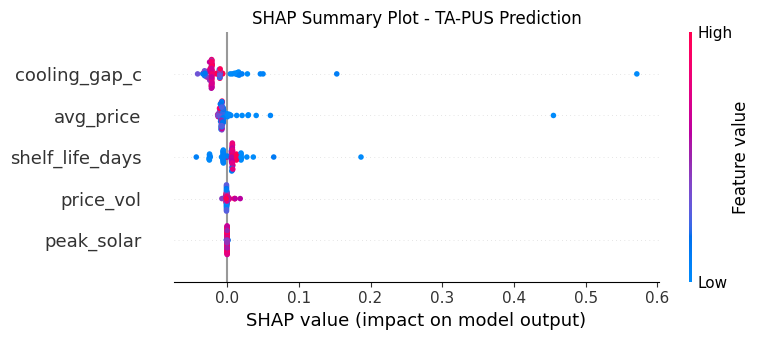

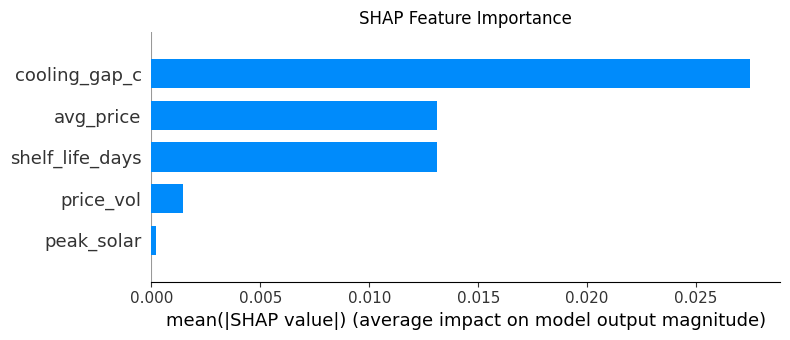


========== SHAP FEATURE IMPORTANCE ==========
        Feature  Mean_SHAP
  cooling_gap_c   0.027475
      avg_price   0.013127
shelf_life_days   0.013091
      price_vol   0.001468
     peak_solar   0.000221

✅ SHAP analysis completed.
✅ Saved:
   • shap_summary.png
   • shap_bar.png
   • shap_feature_importance.csv

=== WHY EACH DISTRICT GOT ITS TA-PUS SCORE ===

       district   crop  TA_PUS_Score      top_driver  shelf_life_contribution  cooling_gap_contribution
          Kolar tomato        1.0000       avg_price                   0.1867                    0.1530
          Kolar  mango        0.7990   cooling_gap_c                   0.0651                    0.5712
Chikkaballapura tomato        0.1864       avg_price                   0.0038                    0.0502
   Vijayanagara tomato        0.0794   cooling_gap_c                   0.0367                   -0.0410
        Raichur  onion        0.0740       avg_price                   0.0076                   -0.0062
     Vij

In [ ]:
# ==========================================================
# SHAP ANALYSIS
# ==========================================================

import shap
import matplotlib.pyplot as plt

print("\nGenerating SHAP analysis...")

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_scaled)

# ----------------------------------------------------------
# SHAP Summary (Dot) Plot
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_scaled,
    show=False
)

plt.title("SHAP Summary Plot - TA-PUS Prediction")
plt.tight_layout()
plt.savefig(f"{CLEANED}/shap_summary.png", dpi=300)
plt.show()

# ----------------------------------------------------------
# SHAP Feature Importance (Bar Plot)
# ----------------------------------------------------------
plt.figure(figsize=(8, 6))

shap.summary_plot(
    shap_values,
    X_scaled,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.savefig(f"{CLEANED}/shap_bar.png", dpi=300)
plt.show()

# ----------------------------------------------------------
# Mean Absolute SHAP Values
# ----------------------------------------------------------
mean_shap = np.abs(shap_values).mean(axis=0)

shap_importance = (
    pd.DataFrame({
        "Feature": feature_cols,
        "Mean_SHAP": mean_shap
    })
    .sort_values("Mean_SHAP", ascending=False)
)

print("\n========== SHAP FEATURE IMPORTANCE ==========")
print(shap_importance.to_string(index=False))

# Save SHAP importance
shap_importance.to_csv(
    f"{CLEANED}/shap_feature_importance.csv",
    index=False
)

print("\n✅ SHAP analysis completed.")
print("✅ Saved:")
print("   • shap_summary.png")
print("   • shap_bar.png")
print("   • shap_feature_importance.csv")

# ── District level explanation ──
# For each district tell WHY it got its TA-PUS score

district_explanations = []

for i, row in df_train.iterrows():
    idx = df_train.index.get_loc(i)
    shap_row = shap_values[idx]

    # Which feature contributed most for THIS district-crop
    contributions = dict(zip(feature_cols, shap_row))
    top_reason = max(contributions, key=lambda k: abs(contributions[k]))

    district_explanations.append({
        'district':     row['district'],
        'crop':         row['crop'],
        'TA_PUS_Score': row['TA_PUS_Score'],
        'top_driver':   top_reason,
        'shelf_life_contribution':  round(contributions['shelf_life_days'], 4),
        'cooling_gap_contribution': round(contributions['cooling_gap_c'], 4),
        'solar_contribution':       round(contributions['peak_solar'], 4),
        'price_vol_contribution':   round(contributions['price_vol'], 4),
        'avg_price_contribution':   round(contributions['avg_price'], 4),
    })

explanation_df = pd.DataFrame(district_explanations)

print("\n=== WHY EACH DISTRICT GOT ITS TA-PUS SCORE ===\n")
print(explanation_df.sort_values('TA_PUS_Score', ascending=False)[[
    'district', 'crop', 'TA_PUS_Score', 'top_driver',
    'shelf_life_contribution', 'cooling_gap_contribution'
]].head(15).to_string(index=False))

# Save
explanation_df.to_csv(f'{CLEANED}/shap_district_explanations.csv', index=False)
print("\n✅ Saved shap_district_explanations.csv")
# ----------------------------------------------------------
# Human readable SHAP explanations per district-crop
# ----------------------------------------------------------

feature_descriptions = {
    'shelf_life_days':   'spoilage speed (Arrhenius)',
    'cooling_gap_c':     'refrigeration demand (temp gap)',
    'peak_solar':        'solar energy availability',
    'price_vol':         'market price instability',
    'avg_price':         'low price = unsold surplus',
    'gap_score':         'cold storage infrastructure gap',
}

print("\n" + "="*65)
print("WHY EACH DISTRICT GOT ITS TA-PUS SCORE")
print("="*65)

top_districts = explanation_df.sort_values(
    'TA_PUS_Score', ascending=False
)

for _, row in top_districts.iterrows():
    # Get all contributions for this row
    contributions = {
        'shelf_life_days': row['shelf_life_contribution'],
        'cooling_gap_c':   row['cooling_gap_contribution'],
        'peak_solar':      row['solar_contribution'],
        'price_vol':       row['price_vol_contribution'],
        'avg_price':       row['avg_price_contribution'],
    }
    if 'gap_score' in feature_cols:
        contributions['gap_score'] = row.get('gap_score_contribution', 0)

    # Sort by absolute contribution
    sorted_contrib = sorted(
        contributions.items(),
        key=lambda x: abs(x[1]),
        reverse=True
    )

    top_feature = sorted_contrib[0][0]
    top_desc    = feature_descriptions.get(top_feature, top_feature)

    print(f"\n{row['district']} {row['crop']} → TA-PUS {row['TA_PUS_Score']:.4f}")
    print(f"  → TOP DRIVER: {top_feature} ({top_desc})")

    for feat, val in sorted_contrib[:3]:
        sign = '+' if val >= 0 else ''
        desc = feature_descriptions.get(feat, feat)
        print(f"  → {feat} contributed {sign}{val:.4f} to score  [{desc}]")

print("\n" + "="*65)